# Analysis 3: Upgraded Fulfillment-Time Proxy Model

This notebook upgrades the existing Analysis 3 model using a single interpretable `RidgeCV` specification on `log1p(hours_to_delivery)`.

The goal is not to build a production ETA engine. The goal is to build a more stable fulfillment-time proxy that can support relative candidate ranking in Part C.

In [60]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import inspect

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
ORDER_LINE_PATH = PROJECT_ROOT / "data" / "processed" / "order_line_with_inventory.csv"
CANDIDATE_PATH = PROJECT_ROOT / "data" / "processed" / "assignment_candidates.csv"

ORDER_LINE_PATH, CANDIDATE_PATH

(WindowsPath('C:/Users/Qiang Gao/Desktop/IE5404-JD/data/processed/order_line_with_inventory.csv'),
 WindowsPath('C:/Users/Qiang Gao/Desktop/IE5404-JD/data/processed/assignment_candidates.csv'))

## 1. Load the processed dataset defensively

In [61]:
def pick_col(df: pd.DataFrame, *candidates: str, required: bool = True) -> str | None:
    for name in candidates:
        if name in df.columns:
            return name
    if required:
        raise KeyError(f"Missing required columns. Tried: {candidates}")
    return None


def stable_holdout_mask(series: pd.Series, train_share: float = 0.8) -> pd.Series:
    hashed = pd.util.hash_pandas_object(series.astype("string"), index=False).astype("uint64")
    return (hashed % 10) < int(train_share * 10)


raw_df = pd.read_csv(ORDER_LINE_PATH)
candidate_df = pd.read_csv(CANDIDATE_PATH) if CANDIDATE_PATH.exists() else None

colmap = {
    "order_line_id": pick_col(raw_df, "order_line_id"),
    "hours_to_delivery": pick_col(raw_df, "hours_to_delivery"),
    "delivered_by_jd_flag": pick_col(raw_df, "delivered_by_jd_flag", required=False),
    "remote_fulfillment_flag": pick_col(raw_df, "remote_fulfillment_flag"),
    "promise_days": pick_col(raw_df, "promise_days", "promise", required=False),
    "quantity": pick_col(raw_df, "quantity"),
    "discount_rate": pick_col(raw_df, "discount_rate"),
    "package_count": pick_col(raw_df, "package_count", required=False),
    "inventory_at_dc_des": pick_col(raw_df, "inventory_at_dc_des"),
    "inventory_at_dc_ori": pick_col(raw_df, "inventory_at_dc_ori"),
    "num_available_dcs_in_region": pick_col(raw_df, "num_available_dcs_in_region"),
    "sku_type_raw": pick_col(raw_df, "type_sku", "sku_type", "type", required=False),
    "plus": pick_col(raw_df, "plus", required=False),
    "user_level": pick_col(raw_df, "user_level", required=False),
    "purchase_power": pick_col(raw_df, "purchase_power", required=False),
    "city_level": pick_col(raw_df, "city_level", required=False),
    "destination_region_id": pick_col(raw_df, "destination_region_id", required=False),
}

print(f"order_line_with_inventory shape: {raw_df.shape}")
print(f"assignment_candidates shape: {candidate_df.shape if candidate_df is not None else 'not available'}")
print(sorted(raw_df.columns.tolist()))

C:\Users\Qiang Gao\AppData\Local\Temp\ipykernel_32940\1656124998.py:15: DtypeWarning: Columns (0: activate_date, 1: deactivate_date) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(ORDER_LINE_PATH)


order_line_with_inventory shape: (549989, 58)
assignment_candidates shape: (3809107, 12)
['activate_date', 'age', 'any_inventory_in_region', 'attribute1', 'attribute2', 'brand_id', 'bundle_discount_per_unit', 'city_level', 'coupon_discount_per_unit', 'dc_des', 'dc_ori', 'deactivate_date', 'delivered_by_jd_flag', 'destination_region_id', 'direct_discount_per_unit', 'discount_consistency_flag', 'discount_gap', 'discount_rate', 'discount_total_per_unit', 'education', 'final_arrival_time', 'final_unit_price', 'first_arr_station_time', 'first_order_month', 'first_ship_out_time', 'gender', 'gift_item', 'gross_merchandise_value', 'hours_to_delivery', 'hours_to_ship', 'inventory_at_dc_des', 'inventory_at_dc_ori', 'is_discounted', 'local_available_but_remote_shipped', 'marital_status', 'net_merchandise_value', 'num_available_dcs_in_region', 'order_date', 'order_hour', 'order_id', 'order_line_id', 'order_time', 'order_weekday', 'order_weekend_flag', 'original_unit_price', 'package_count', 'plus'

## 2. Build the modeling sample

Filtering rules:
- keep JD-logged rows if `delivered_by_jd_flag` exists,
- require non-missing `hours_to_delivery`,
- keep only positive hours,
- apply a light-touch outlier filter: `hours_to_delivery <= 240`.

In [62]:
def build_modeling_sample(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(
        {
            "order_line_id": df[colmap["order_line_id"]].astype("string"),
            "hours_to_delivery": pd.to_numeric(df[colmap["hours_to_delivery"]], errors="coerce"),
            "remote_fulfillment_flag": pd.to_numeric(df[colmap["remote_fulfillment_flag"]], errors="coerce"),
            "promise_days": pd.to_numeric(df[colmap["promise_days"]], errors="coerce") if colmap["promise_days"] else np.nan,
            "quantity": pd.to_numeric(df[colmap["quantity"]], errors="coerce"),
            "discount_rate": pd.to_numeric(df[colmap["discount_rate"]], errors="coerce"),
            "package_count": pd.to_numeric(df[colmap["package_count"]], errors="coerce") if colmap["package_count"] else np.nan,
            "inventory_at_fulfillment_dc": pd.to_numeric(df[colmap["inventory_at_dc_ori"]], errors="coerce"),
            "num_available_dcs_in_region": pd.to_numeric(df[colmap["num_available_dcs_in_region"]], errors="coerce"),
            "plus": pd.to_numeric(df[colmap["plus"]], errors="coerce") if colmap["plus"] else np.nan,
            "user_level": pd.to_numeric(df[colmap["user_level"]], errors="coerce") if colmap["user_level"] else np.nan,
            "purchase_power": pd.to_numeric(df[colmap["purchase_power"]], errors="coerce") if colmap["purchase_power"] else np.nan,
            "city_level": pd.to_numeric(df[colmap["city_level"]], errors="coerce") if colmap["city_level"] else np.nan,
            "destination_region_id": pd.to_numeric(df[colmap["destination_region_id"]], errors="coerce") if colmap["destination_region_id"] else np.nan,
        }
    )

    if colmap["delivered_by_jd_flag"]:
        out["delivered_by_jd_flag"] = pd.to_numeric(df[colmap["delivered_by_jd_flag"]], errors="coerce")
        out = out.loc[out["delivered_by_jd_flag"] == 1].copy()

    out = out.loc[out["hours_to_delivery"].notna()].copy()
    out = out.loc[out["hours_to_delivery"] > 0].copy()
    out = out.loc[out["hours_to_delivery"] <= 240].copy()

    sku_type_series = pd.to_numeric(df[colmap["sku_type_raw"]], errors="coerce") if colmap["sku_type_raw"] else pd.Series(np.nan, index=df.index)
    out["sku_type"] = np.select(
        [sku_type_series.loc[out.index].eq(1), sku_type_series.loc[out.index].eq(2)],
        ["1P", "3P"],
        default="Unknown",
    )

    out["promise_missing_flag"] = out["promise_days"].isna().astype(int)
    out["package_missing_flag"] = out["package_count"].isna().astype(int)
    out["region_missing_flag"] = out["destination_region_id"].isna().astype(int)
    out["log_hours_to_delivery"] = np.log1p(out["hours_to_delivery"])
    return out.reset_index(drop=True)


df_model = build_modeling_sample(raw_df)
train_mask = stable_holdout_mask(df_model["order_line_id"])

print(f"Raw processed rows: {len(raw_df):,}")
print(f"Modeling sample rows: {len(df_model):,}")
print(f"Train rows: {train_mask.sum():,}")
print(f"Test rows: {(~train_mask).sum():,}")

df_model[["hours_to_delivery", "log_hours_to_delivery"]].describe()

Raw processed rows: 549,989
Modeling sample rows: 326,238
Train rows: 261,231
Test rows: 65,007


,hours_to_delivery,log_hours_to_delivery
count,326238.000000,326238.000000
mean,34.142704,3.329984
std,27.012676,0.662620
min,0.486667,0.396536
25%,17.501667,2.917861
50%,23.833472,3.212192
75%,44.135000,3.809658
max,239.848056,5.484166


## 3. Feature design

Core features:
- `remote_fulfillment_flag`
- `promise_days`
- `quantity`
- `discount_rate`
- `package_count`
- `inventory_at_fulfillment_dc`
- `num_available_dcs_in_region`
- `sku_type`
- `plus`
- `user_level`
- `purchase_power`
- `city_level`
- `destination_region_id`

Business-motivated interactions:
- `remote_x_inventory_at_fulfillment_dc`
- `remote_x_package_count`
- `remote_x_promise_days`
- `remote_x_sku_type_3p`

In [63]:
def add_business_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["sku_type_3p_flag"] = (out["sku_type"] == "3P").astype(float)
    out["remote_x_inventory_at_fulfillment_dc"] = out["remote_fulfillment_flag"] * out["inventory_at_fulfillment_dc"]
    out["remote_x_package_count"] = out["remote_fulfillment_flag"] * out["package_count"]
    out["remote_x_promise_days"] = out["remote_fulfillment_flag"] * out["promise_days"]
    out["remote_x_sku_type_3p"] = out["remote_fulfillment_flag"] * out["sku_type_3p_flag"]
    return out


df_model = add_business_features(df_model)

numeric_features = [
    "remote_fulfillment_flag",
    "promise_days",
    "promise_missing_flag",
    "quantity",
    "discount_rate",
    "package_count",
    "package_missing_flag",
    "inventory_at_fulfillment_dc",
    "num_available_dcs_in_region",
    "plus",
    "user_level",
    "purchase_power",
    "city_level",
    "remote_x_inventory_at_fulfillment_dc",
    "remote_x_package_count",
    "remote_x_promise_days",
    "remote_x_sku_type_3p",
]

categorical_features = [
    "sku_type",
    "destination_region_id",
]

feature_columns = numeric_features + categorical_features

X_train_raw = df_model.loc[train_mask, feature_columns].copy()
X_test_raw = df_model.loc[~train_mask, feature_columns].copy()
y_train_log = df_model.loc[train_mask, "log_hours_to_delivery"].copy()
y_test_hours = df_model.loc[~train_mask, "hours_to_delivery"].copy()

X_train_raw.head()

,remote_fulfillment_flag,promise_days,promise_missing_flag,quantity,discount_rate,package_count,package_missing_flag,inventory_at_fulfillment_dc,num_available_dcs_in_region,plus,user_level,purchase_power,city_level,remote_x_inventory_at_fulfillment_dc,remote_x_package_count,remote_x_promise_days,remote_x_sku_type_3p,sku_type,destination_region_id
0,0,2.0,0,1,0.460460,1.0,0,0,6,0,1,3,2,0,0.0,0.0,0.0,1P,4.0
2,1,2.0,0,1,0.426230,1.0,0,1,7,0,3,2,2,1,1.0,2.0,0.0,Unknown,4.0
3,1,1.0,0,1,0.320513,1.0,0,1,0,0,1,4,2,1,1.0,1.0,0.0,Unknown,NaN
4,1,1.0,0,1,0.513141,1.0,0,1,0,0,2,2,2,1,1.0,1.0,0.0,1P,NaN
5,1,1.0,0,1,NaN,1.0,0,1,0,0,2,-1,2,1,1.0,1.0,0.0,1P,NaN


## 4. Preprocessing pipeline

Preprocessing choices:
- median imputation for numeric predictors,
- most-frequent imputation for categorical predictors,
- standardization for numeric predictors,
- one-hot encoding for `sku_type` and `destination_region_id`,
- IDs are excluded from the model.

In [64]:
def make_onehot_encoder():
    params = inspect.signature(OneHotEncoder).parameters
    if "sparse_output" in params:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    if "sparse" in params:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)
    return OneHotEncoder(handle_unknown="ignore")


numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

alphas = np.array([0.01, 0.1, 1.0, 3.0, 10.0, 30.0, 100.0])

ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("ridge", RidgeCV(alphas=alphas, cv=5)),
    ]
)


## 5. Main model code

In [65]:
ridge_pipeline.fit(X_train_raw, y_train_log)

pred_test_log = ridge_pipeline.predict(X_test_raw)
pred_test_hours = np.expm1(pred_test_log)
pred_test_hours = np.clip(pred_test_hours, a_min=0, a_max=None)

selected_alpha = ridge_pipeline.named_steps["ridge"].alpha_
selected_alpha

np.float64(100.0)

## 6. Evaluation results

Evaluation is reported on the original hours scale, not the log scale.

In [66]:
rmse = float(np.sqrt(mean_squared_error(y_test_hours, pred_test_hours)))
mae = mean_absolute_error(y_test_hours, pred_test_hours)
r2 = r2_score(y_test_hours, pred_test_hours)

evaluation_table = pd.DataFrame(
    {
        "metric": ["RMSE", "MAE", "R2", "Selected alpha"],
        "value": [rmse, mae, r2, selected_alpha],
    }
)
evaluation_table

,metric,value
0,RMSE,20.053595
1,MAE,11.314186
2,R2,0.438062
3,Selected alpha,100.000000


## 7. Coefficient interpretation

The coefficient table below is shown on the standardized feature scale used by the fitted Ridge model. Coefficients should be interpreted directionally and comparatively, not causally.

In [67]:
feature_names = ridge_pipeline.named_steps["preprocessor"].get_feature_names_out()
ridge_coef = ridge_pipeline.named_steps["ridge"].coef_

coef_table = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": ridge_coef,
        "abs_coefficient": np.abs(ridge_coef),
    }
).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

coef_table.head(25)

,feature,coefficient,abs_coefficient
0,num__promise_days,0.413887,0.413887
1,cat__destination_region_id_2.0,-0.084046,0.084046
2,cat__destination_region_id_4.0,0.078168,0.078168
3,cat__destination_region_id_10.0,-0.076607,0.076607
4,num__remote_x_promise_days,-0.067637,0.067637
5,cat__destination_region_id_9.0,0.066438,0.066438
6,num__inventory_at_fulfillment_dc,-0.046823,0.046823
7,num__discount_rate,0.046308,0.046308
8,num__promise_missing_flag,0.041345,0.041345
9,cat__destination_region_id_24.0,0.040809,0.040809


In [68]:
focus_patterns = [
    "remote_fulfillment_flag",
    "inventory_at_fulfillment_dc",
    "num_available_dcs_in_region",
    "package_count",
    "promise_days",
    "remote_x_",
    "sku_type",
]

coef_focus = coef_table.loc[
    coef_table["feature"].apply(lambda x: any(pattern in x for pattern in focus_patterns))
].reset_index(drop=True)
coef_focus.head(30)

,feature,coefficient,abs_coefficient
0,num__promise_days,0.413887,0.413887
1,num__remote_x_promise_days,-0.067637,0.067637
2,num__inventory_at_fulfillment_dc,-0.046823,0.046823
3,num__remote_x_package_count,0.038577,0.038577
4,cat__sku_type_1P,-0.037814,0.037814
5,cat__sku_type_3P,0.034578,0.034578
6,num__remote_fulfillment_flag,0.034490,0.034490
7,num__num_available_dcs_in_region,-0.028683,0.028683
8,num__remote_x_inventory_at_fulfillment_dc,0.019601,0.019601
9,num__remote_x_sku_type_3p,0.010303,0.010303


## 8. Light diagnostics

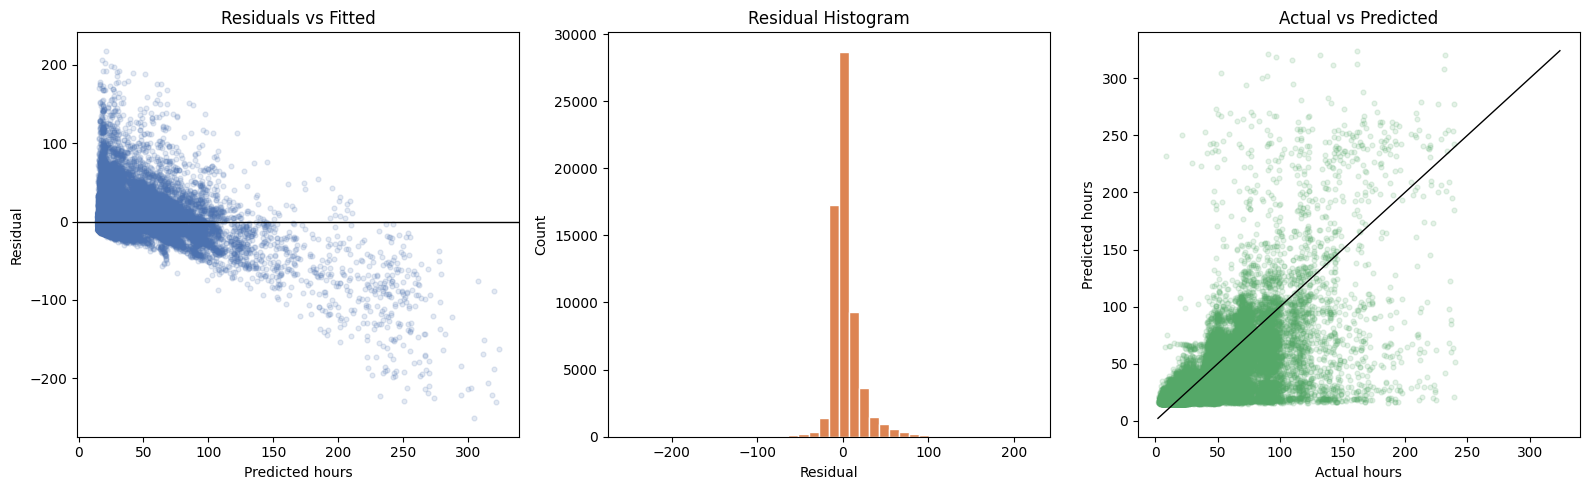

In [69]:
residuals_hours = y_test_hours - pred_test_hours

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(pred_test_hours, residuals_hours, alpha=0.15, s=12, color="#4C72B0")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Residuals vs Fitted")
axes[0].set_xlabel("Predicted hours")
axes[0].set_ylabel("Residual")

axes[1].hist(residuals_hours, bins=40, color="#DD8452", edgecolor="white")
axes[1].set_title("Residual Histogram")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")

axes[2].scatter(y_test_hours, pred_test_hours, alpha=0.15, s=12, color="#55A868")
diag_min = min(y_test_hours.min(), pred_test_hours.min())
diag_max = max(y_test_hours.max(), pred_test_hours.max())
axes[2].plot([diag_min, diag_max], [diag_min, diag_max], color="black", linewidth=1)
axes[2].set_title("Actual vs Predicted")
axes[2].set_xlabel("Actual hours")
axes[2].set_ylabel("Predicted hours")

plt.tight_layout()
plt.show()

## 9. Candidate scoring redesign for Part C

Important distinction:
- training uses realized historical fulfillment outcomes,
- candidate scoring must rebuild the same feature concepts for each hypothetical `candidate_dc`.

In particular:
- do not reuse realized `dc_ori`-dependent fields directly,
- do use candidate-specific remote and inventory variables.

In [70]:
candidate_mapping = pd.DataFrame(
    [
        {
            "concept": "remote_fulfillment_flag",
            "historical_training_version": "observed remote_fulfillment_flag",
            "candidate_scoring_version": "candidate_remote_flag or 1(candidate_dc != dc_des)",
        },
        {
            "concept": "inventory_at_fulfillment_dc",
            "historical_training_version": "inventory_at_dc_ori for the actual fulfillment warehouse",
            "candidate_scoring_version": "inventory_available for (order_date, sku_id, candidate_dc)",
        },
        {
            "concept": "num_available_dcs_in_region",
            "historical_training_version": "num_available_dcs_in_region",
            "candidate_scoring_version": "same region-level stock flexibility merged from order-line data",
        },
    ]
)
candidate_mapping

,concept,historical_training_version,candidate_scoring_version
0,remote_fulfillment_flag,observed remote_fulfillment_flag,candidate_remote_flag or 1(candidate_dc != dc_...
1,inventory_at_fulfillment_dc,inventory_at_dc_ori for the actual fulfillment...,"inventory_available for (order_date, sku_id, c..."
2,num_available_dcs_in_region,num_available_dcs_in_region,same region-level stock flexibility merged fro...


In [71]:
def build_candidate_feature_frame(candidate_rows: pd.DataFrame, order_line_df: pd.DataFrame) -> pd.DataFrame:
    static_cols = [
        "order_line_id",
        "quantity",
        "discount_rate",
        "promise_days",
        "plus",
        "user_level",
        "purchase_power",
        "city_level",
        "destination_region_id",
        "num_available_dcs_in_region",
        "package_count",
        "sku_type",
    ]
    available_static_cols = [col for col in static_cols if col in order_line_df.columns]
    static_lookup = order_line_df[available_static_cols].drop_duplicates(subset=["order_line_id"]).copy()
    work = candidate_rows.copy().merge(static_lookup, how="left", on="order_line_id", validate="m:1", suffixes=("", "_hist"))

    if "destination_region_id" not in work.columns:
        if "destination_region_id_hist" in work.columns:
            work["destination_region_id"] = work["destination_region_id_hist"]
        elif "destination_region_id" in candidate_rows.columns:
            work["destination_region_id"] = candidate_rows["destination_region_id"]
        else:
            work["destination_region_id"] = np.nan
    elif work["destination_region_id"].isna().all() and "destination_region_id_hist" in work.columns:
        work["destination_region_id"] = work["destination_region_id"].fillna(work["destination_region_id_hist"])

    work["remote_fulfillment_flag"] = pd.to_numeric(work["candidate_remote_flag"], errors="coerce")
    work["inventory_at_fulfillment_dc"] = pd.to_numeric(work["inventory_available"], errors="coerce")
    work["promise_missing_flag"] = pd.to_numeric(work["promise_days"], errors="coerce").isna().astype(int)
    work["package_missing_flag"] = pd.to_numeric(work["package_count"], errors="coerce").isna().astype(int)
    return add_business_features(work)


def score_assignment_candidates(
    candidate_rows: pd.DataFrame,
    order_line_df: pd.DataFrame,
    fitted_pipeline: Pipeline,
    package_count_assumption: str = "median",
) -> pd.DataFrame:
    work = build_candidate_feature_frame(candidate_rows=candidate_rows, order_line_df=order_line_df)

    if package_count_assumption == "median":
        work["package_count"] = work["package_count"].fillna(order_line_df["package_count"].median())
    elif package_count_assumption == "one":
        work["package_count"] = work["package_count"].fillna(1.0)
    else:
        raise ValueError("package_count_assumption must be 'median' or 'one'.")

    model_input = work[feature_columns].copy()
    pred_log = fitted_pipeline.predict(model_input)
    work["predicted_hours_to_delivery"] = np.clip(np.expm1(pred_log), a_min=0, a_max=None)
    return work


if candidate_df is not None:
    scored_candidates = score_assignment_candidates(
        candidate_rows=candidate_df.head(1000).copy(),
        order_line_df=df_model,
        fitted_pipeline=ridge_pipeline,
        package_count_assumption="median",
    )
    scored_candidates[
        [
            "order_line_id",
            "candidate_dc",
            "candidate_remote_flag",
            "inventory_available",
            "predicted_hours_to_delivery",
        ]
    ].head(10)
else:
    print("assignment_candidates.csv not available")

## 10. Interpretation notes for the course report

- This model is an interpretable fulfillment-time proxy, not a precise ETA engine.
- The log target helps stabilize extreme delivery times and makes the Ridge model less sensitive to long-tail outcomes.
- Inventory is only binary availability in the processed dataset, so it should be interpreted as coarse stock context rather than exact operational depth.
- `promise_days` is useful as a predictor, but it partly reflects platform promise design rather than pure operational physics.
- 3P delivery coverage may differ from 1P in the observed JD-logged sample.
- For Part C, the main use is relative ranking across candidate assignments, not exact hour prediction.